In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\tanay\Downloads\housing_raw (2).csv")

In [2]:
df

,size_sqft,bedrooms,age_years,price
0,1096.795684,5.0,19.071726,192551.626947
1,2288.258214,3.0,12.127341,340558.678039
2,2021.013968,5.0,20.102068,305290.476552
3,1704.819098,1.0,13.307253,256093.393566
4,2514.685772,1.0,27.436424,290795.192718
...,...,...,...,...
510,1789.919305,3.0,9.282433,253973.622097
511,2098.296446,3.0,12.463207,320306.914263
512,1692.233152,5.0,0.000000,310613.708230
513,NaN,3.0,27.998872,375119.542386


In [3]:
df.isnull().sum()

size_sqft    20
bedrooms     20
age_years    21
price        21
dtype: int64

In [4]:
nums = []
for i in df.columns:
    if df[i].dtype == "int64" or df[i].dtype == "float64": 
        nums.append(i)
print(nums)

['size_sqft', 'bedrooms', 'age_years', 'price']


In [5]:
Cnums = ['bedrooms','size_sqft',  'age_years', 'price']
for i in nums:
    if i in df.columns:
        df[i] = df[i].fillna(df[i].median())

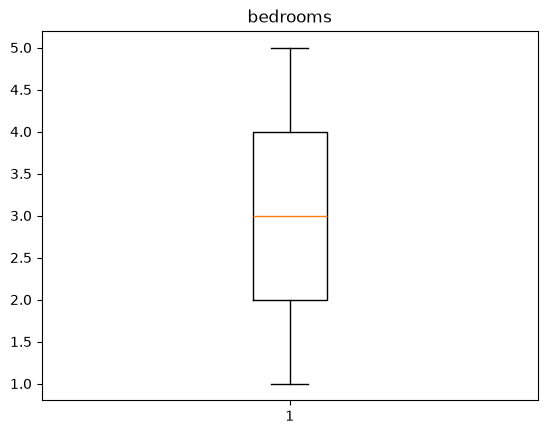

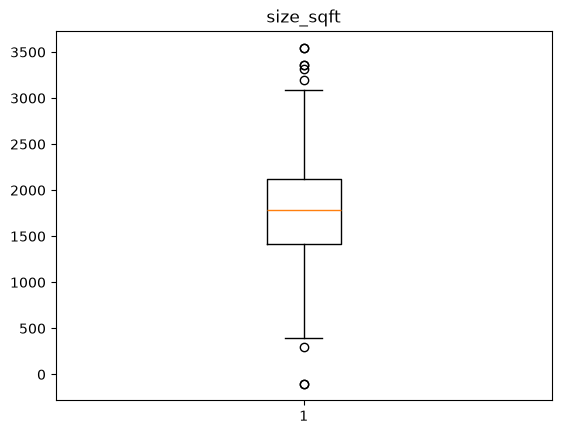

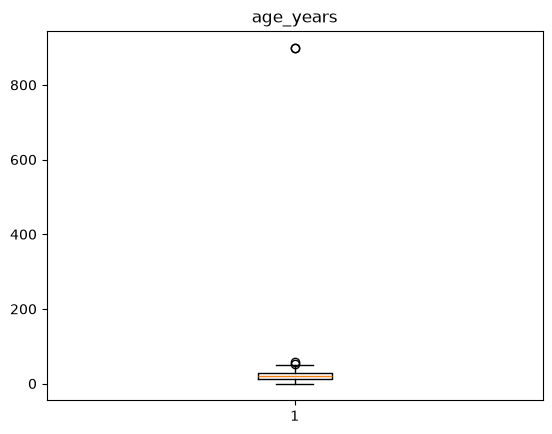

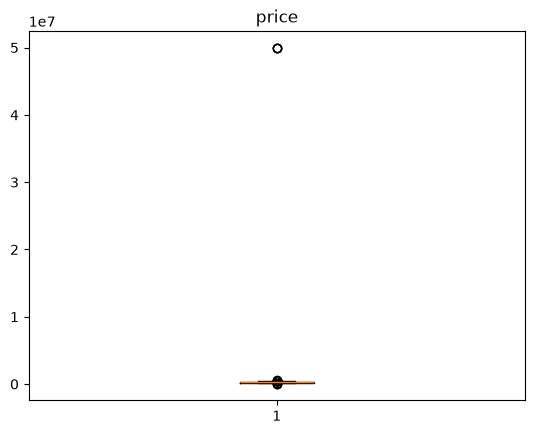

In [6]:
import matplotlib.pyplot as plt
for i in nums:
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [7]:
outliers = ['size_sqft',  'age_years', 'price']
for i in outliers:
    if i in df.columns:
        Q1 = df[i].quantile(0.25)
        Q3 = df[i].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        median = df[i].median()
        df.loc[(df[i]<lower) | (df[i]>upper),i] = median

In [8]:
df.isnull().sum()

size_sqft    0
bedrooms     0
age_years    0
price        0
dtype: int64

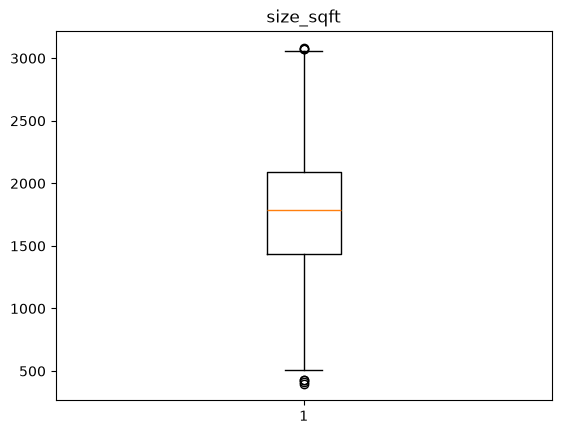

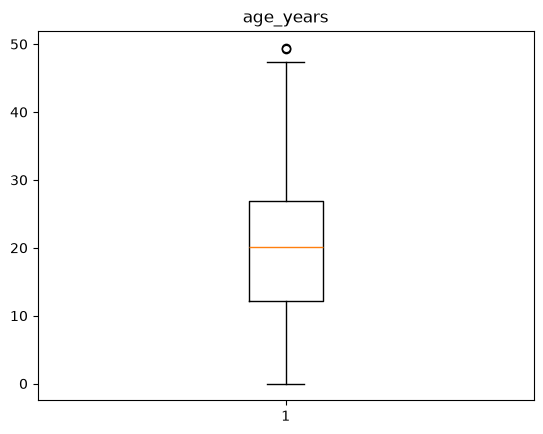

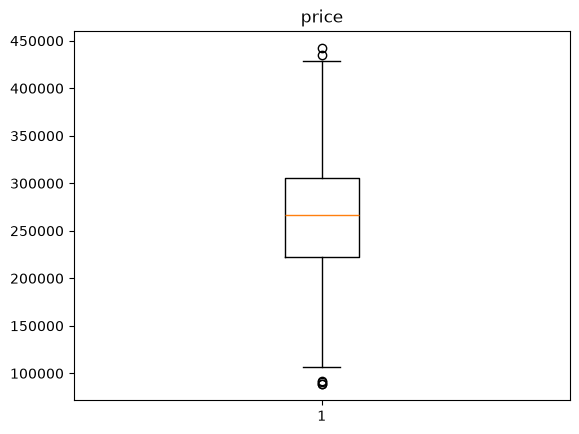

In [9]:
for i in outliers:
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [10]:
x = df.iloc[:,0:3]

In [11]:
x.shape

(515, 3)

In [12]:
y = df.iloc[:,-1]

In [13]:
y.shape

(515,)

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size = 0.2,random_state = 42)


In [15]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()


In [16]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[55685.54,18184.02,-9576.51]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.644e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[21.3 ,20.51,19.01]"


In [18]:
y_pred = lr.predict(x_test)

In [20]:
pd.concat([pd.Series(y_pred),y_test.reset_index(drop=True)],axis=1)

,0,price
0,373665.327682,386209.733112
1,174449.684769,191903.827821
2,343182.775901,345867.576626
3,200476.259366,157970.852861
4,169842.921552,160152.918503
...,...,...
98,366569.437440,378557.291194
99,270309.619469,365973.392667
100,234483.467448,238135.922019
101,303930.829741,317051.735482


In [23]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score,mean_squared_error
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 20230.982977979795
MSE: 967745025.7030102
RMSE: 31108.6005101967
R2 Score: 0.7852389334043417


In [27]:
#Applying Gradient descent
weights = np.zeros(x_train.shape[1])
bias = 0
alpha = 0.01
for epoch in range(1000):
    y_train_pred = np.dot(x_train,weights)+bias
    dw = (-2/len(x_train))*x_train.T.dot(y_train-y_train_pred)
    db = (-2/len(x_train))*np.sum(y_train-y_train_pred)
    
    weights = weights-alpha*dw
    bias = bias - alpha*db

    
    

In [28]:
y_test_pred = np.dot(x_test, weights) + bias

In [29]:
print(y_test_pred)

[373665.32605199 174449.685107   343182.77476267 200476.25983955
 169842.92246778 126961.97875636 225474.08976647 276020.28419463
 239374.44213304 353204.84407301 288788.06084547 299592.58950096
 334375.36066183 239005.97247464 325226.0782077  274576.02609742
 368078.2131915  294177.82497568 287281.51636013 248026.69525638
 337256.2695836  323573.72798914 192968.96503665 283442.48435668
 197668.50102048 187831.7093589  279722.01196777 189260.39540309
 282720.35625911 282411.14767632 325115.91023917 321095.76557088
 248287.67892173 305680.06336261 297915.10207047 270242.33197181
 239562.9986859  253943.00191407 254961.84334059 228922.32693184
 230413.91138473 228823.49517771 358807.524006   212850.94008198
 287100.51511082 220800.23148647 296542.81088574 299879.12756316
 287033.92274687 187487.46623942 285382.61804534 244740.52984371
 233993.83427322 280194.27010643 389714.75616055 288645.93910663
 316806.76786341 271841.44685999 182137.55597507 348489.16161212
 306714.91978279 365961.6

In [30]:
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("RMSE:", rmse)
print("R2 Score:", r2_score(y_test, y_test_pred))

MAE: 20230.98312363432
MSE: 967745036.1383814
RMSE: 31108.600677921553
R2 Score: 0.7852389310885339
